# CSZ — minimum tsunami arrival times at the coast

The most practical question for a Cascadia Subduction Zone (CSZ) earthquake is:
**how many minutes after the shaking stops does the first damaging tsunami wave arrive?**

We answer this by distributing sources along the `CSZ_max_def` line — a path between
the offshore trench and the coast that approximates where the seafloor deformation
is largest. Rays are traced from all sources simultaneously; `grid_travel_times`
automatically keeps the minimum first-arrival time across all sources at every
grid cell. We then read off that minimum at a dense set of coastal points along
the US (northern California → Washington) and Canadian (British Columbia) coasts.

**Note:** the most damaging wave in a great CSZ earthquake will likely come from
closer to the trench and arrive later. The arrivals computed here represent an
upper bound on warning time from the near-field deformation zone.

**Bathymetry:** SRTM30+ 30 arc-second grid (`data/cascadia.xyz`, Git LFS).

> Requires `scipy`:  `pip install -e ".[examples]"`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
import TsunamiTrace as tt
%matplotlib inline

## Load bathymetry

In [2]:
print('Loading data/cascadia.xyz ...', end='', flush=True)
lon_arr, lat_arr, depth_tracing = tt.load_bathymetry('../data/cascadia.xyz')
print(' done.')

# depth_grid: (n_lat, n_lon) with geographic sign (negative = ocean) for plotting
depth_grid = -depth_tracing.T

n_lon, n_lat = depth_tracing.shape
print(f'Grid : {n_lon} × {n_lat}  (spacing {lon_arr[1]-lon_arr[0]:.5f}°)')
print(f'Lon  : {lon_arr[0]:.3f} to {lon_arr[-1]:.3f} °')
print(f'Lat  : {lat_arr[0]:.3f} to {lat_arr[-1]:.3f} °N')

Loading data/cascadia.xyz ... done.
Grid : 1080 × 1560  (spacing 0.00833°)
Lon  : -131.996 to -123.004 °
Lat  : 39.004 to 51.996 °N


## Load and interpolate CSZ paths

All four files are sparse polylines; we resample them to evenly spaced points
using arc-length interpolation along each path.

- **`CSZ_max_def`** → source locations (seafloor deformation zone)
- **`CSZ_US_coast`** → US coastal receiver points (N. California → Washington)
- **`CSZ_CA_coast`** → Canadian coastal receiver points (British Columbia)
- **`CSZ_trench`** → trench axis, plotting only

In [3]:
def interpolate_along_path(lon, lat, n_out):
    """Resample a lon/lat polyline to n_out evenly spaced (by arc length) points."""
    cos_mid = np.cos(np.radians(0.5 * (lat[:-1] + lat[1:])))
    dlon_km = np.diff(lon) * cos_mid * 111.3
    dlat_km = np.diff(lat) * 111.3
    seg_km  = np.sqrt(dlon_km**2 + dlat_km**2)
    arc     = np.concatenate([[0.0], np.cumsum(seg_km)])
    s       = arc / arc[-1]
    s_new   = np.linspace(0.0, 1.0, n_out)
    return interp1d(s, lon)(s_new), interp1d(s, lat)(s_new)


# ── raw paths ─────────────────────────────────────────────────────────────────
# max_def and trench use '#' comments; coast files use GMT '> -L"..."' headers
max_def_raw = np.loadtxt('../data/CSZ_max_def.txt', comments='#')
trench_raw  = np.loadtxt('../data/CSZ_trench.txt',  comments='#')
us_raw      = np.loadtxt('../data/CSZ_US_coast.txt', comments='>')
ca_raw      = np.loadtxt('../data/CSZ_CA_coast.txt', comments='>')

# ── interpolated paths ────────────────────────────────────────────────────────
N_SOURCES  = 150   # source points along max_def
N_US_COAST = 200   # US coastal receiver points
N_CA_COAST = 150   # Canadian coastal receiver points

src_lons,    src_lats    = interpolate_along_path(max_def_raw[:, 0], max_def_raw[:, 1], N_SOURCES)
us_coast_lon, us_coast_lat = interpolate_along_path(us_raw[:, 0], us_raw[:, 1], N_US_COAST)
ca_coast_lon, ca_coast_lat = interpolate_along_path(ca_raw[:, 0], ca_raw[:, 1], N_CA_COAST)

print(f'Sources (max_def) : {N_SOURCES}  '
      f'({src_lons.min():.2f}–{src_lons.max():.2f}°, '
      f'{src_lats.min():.2f}–{src_lats.max():.2f}°N)')
print(f'US coast points   : {N_US_COAST}  '
      f'({us_coast_lon.min():.2f}–{us_coast_lon.max():.2f}°, '
      f'{us_coast_lat.min():.2f}–{us_coast_lat.max():.2f}°N)')
print(f'CA coast points   : {N_CA_COAST}  '
      f'({ca_coast_lon.min():.2f}–{ca_coast_lon.max():.2f}°, '
      f'{ca_coast_lat.min():.2f}–{ca_coast_lat.max():.2f}°N)')

Sources (max_def) : 150  (-130.29–-124.46°, 40.50–51.64°N)
US coast points   : 200  (-124.76–-123.89°, 40.27–48.40°N)
CA coast points   : 150  (-128.44–-123.89°, 48.37–50.90°N)


## Overview map — paths, sources, and coastal receivers

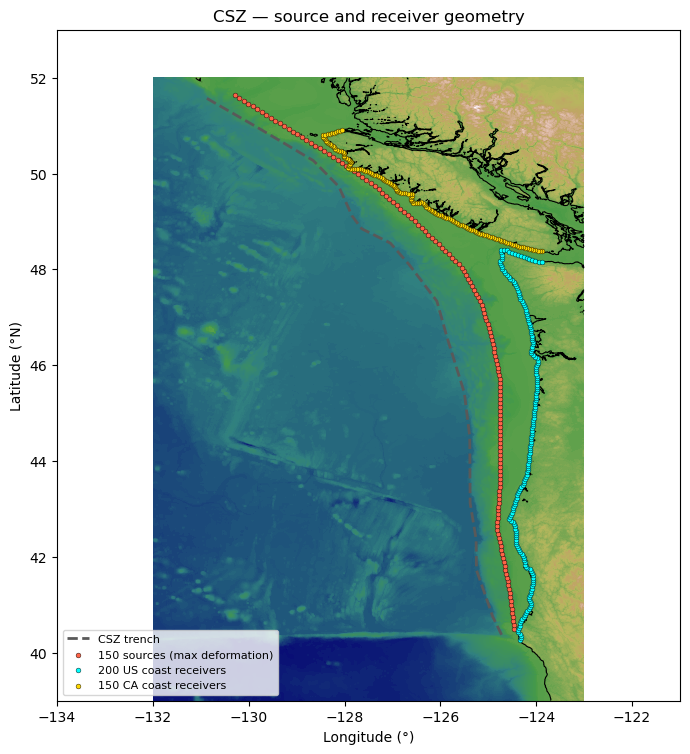

In [4]:
vmin_d = float(np.nanmin(depth_grid))
vmax_d = float(np.nanmax(depth_grid))
norm_bathy = mcolors.TwoSlopeNorm(vmin=vmin_d, vcenter=0, vmax=max(vmax_d, 1))

# Map extent — Cascadia region
LON_MIN, LON_MAX = -134.0, -121.0
LAT_MIN, LAT_MAX =   39.0,   53.0

fig, ax = plt.subplots(figsize=(7, 10))

ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=100, cmap='gist_earth', norm=norm_bathy)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Trench axis
ax.plot(trench_raw[:, 0], trench_raw[:, 1],
        color='0.35', linewidth=2.0, linestyle='--', zorder=4, label='CSZ trench')

# Source path + points
ax.plot(max_def_raw[:, 0], max_def_raw[:, 1],
        color='tomato', linewidth=1.5, zorder=4)
ax.scatter(src_lons, src_lats,
           s=12, c='tomato', edgecolors='k', linewidths=0.3,
           zorder=5, label=f'{N_SOURCES} sources (max deformation)')

# Coast points
ax.scatter(us_coast_lon, us_coast_lat,
           s=12, c='cyan', edgecolors='k', linewidths=0.3,
           zorder=5, label=f'{N_US_COAST} US coast receivers')
ax.scatter(ca_coast_lon, ca_coast_lat,
           s=12, c='gold', edgecolors='k', linewidths=0.3,
           zorder=5, label=f'{N_CA_COAST} CA coast receivers')

ax.set_xlim([LON_MIN, LON_MAX])
ax.set_ylim([LAT_MIN, LAT_MAX])
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('CSZ — source and receiver geometry')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## Tsunami ray tracing — all sources simultaneously

`trace_rays` integrates all 150 sources in a single vectorised RK4 pass,
returning shape `(n_sources, n_azimuths, n_steps)`.  `grid_travel_times` then
uses `statistic='min'` when binning, so the minimum travel time across all
sources is retained at every geographic bin automatically.

In [5]:
DT       = 30.0                                   # time step (s)
MAX_TIME = 2 * 3600.0                             # 2 hours
AZIMUTHS = np.arange(0, 360, 0.1, dtype=float)   # 360 azimuths per source

n_total = N_SOURCES * len(AZIMUTHS)
print(f'Sources  : {N_SOURCES}')
print(f'Rays/src : {len(AZIMUTHS)}  (every {AZIMUTHS[1]-AZIMUTHS[0]:.1f}°)')
print(f'Total    : {n_total:,} rays')
print(f'dt       : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print('Tracing ...', end='', flush=True)

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    src_lons, src_lats,
    AZIMUTHS,
)

print(f'  done.  Output shape: {ray_lon.shape}')

Sources  : 150
Rays/src : 3600  (every 0.1°)
Total    : 540,000 rays
dt       : 30 s    max time : 2 h
Tracing ...  done.  Output shape: (150, 3600, 242)


## Grid minimum travel times

Flatten the `(n_sources, n_azimuths, n_steps)` output to `(n_rays, n_steps)`
before passing to `grid_travel_times`.  The `'min'` statistic in
`binned_statistic_2d` handles the across-source minimum internally.

In [6]:
n_src, n_az, n_st = ray_lon.shape
ray_lon_flat = ray_lon.reshape(n_src * n_az, n_st)
ray_lat_flat = ray_lat.reshape(n_src * n_az, n_st)

BIN_DEG = 0.1   # ~11 km — fine enough to resolve coast–source timing

print('Gridding travel times ...', end='', flush=True)
lon_bin, lat_bin, travel_time = tt.grid_travel_times(
    ray_lon_flat, ray_lat_flat, DT,
    lon_arr, lat_arr, depth_tracing,
    bin_deg=BIN_DEG,
    fill=True,
)
print(f' done.  Output grid: {len(lon_bin)} × {len(lat_bin)}')

# Convert hours → minutes for all displays in this notebook
travel_time_min = travel_time * 60.0
print(f'Travel time range: {np.nanmin(travel_time_min):.1f} – {np.nanmax(travel_time_min):.1f} min')

Gridding travel times ... done.  Output grid: 91 × 131
Travel time range: 0.0 – 96.0 min


## Minimum arrival times at coastal receivers

For each coast point we find the nearest bin in the travel-time grid.
Because the grid already holds the minimum across all sources, no additional
reduction is needed.

In [7]:
def sample_grid(lons, lats, lon_bin, lat_bin, grid_min):
    """Sample a (n_lat_bin, n_lon_bin) grid at a set of lon/lat points."""
    i_lons = np.argmin(np.abs(lon_bin[:, None] - lons[None, :]), axis=0)
    i_lats = np.argmin(np.abs(lat_bin[:, None] - lats[None, :]), axis=0)
    return grid_min[i_lats, i_lons]


us_arrival_min = sample_grid(us_coast_lon, us_coast_lat, lon_bin, lat_bin, travel_time_min)
ca_arrival_min = sample_grid(ca_coast_lon, ca_coast_lat, lon_bin, lat_bin, travel_time_min)

# Summary statistics
for label, arr_min, lats in [
    ('US coast (CA–WA)', us_arrival_min, us_coast_lat),
    ('CA coast (BC)',    ca_arrival_min, ca_coast_lat),
]:
    valid = ~np.isnan(arr_min)
    imin  = np.nanargmin(arr_min)
    imax  = np.nanargmax(arr_min)
    print(f'  {label}')
    print(f'    Valid points : {valid.sum()} / {len(arr_min)}')
    print(f'    Minimum      : {arr_min[imin]:.1f} min  (lat {lats[imin]:.2f}°N)')
    print(f'    Maximum      : {arr_min[imax]:.1f} min  (lat {lats[imax]:.2f}°N)')
    print(f'    Median       : {np.nanmedian(arr_min):.1f} min')

  US coast (CA–WA)
    Valid points : 132 / 200
    Minimum      : 1.0 min  (lat 40.48°N)
    Maximum      : 83.0 min  (lat 48.28°N)
    Median       : 21.0 min
  CA coast (BC)
    Valid points : 111 / 150
    Minimum      : 1.5 min  (lat 50.18°N)
    Maximum      : 54.0 min  (lat 48.41°N)
    Median       : 15.5 min


## Travel time map with coastal arrival times

/var/folders/5x/5xtm6r7126g41vdgwb462xp40000gn/T/ipykernel_67790/799924749.py:58: UserWarning: Adding colorbar to a different Figure <Figure size 700x1000 with 2 Axes> than <Figure size 700x1000 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)


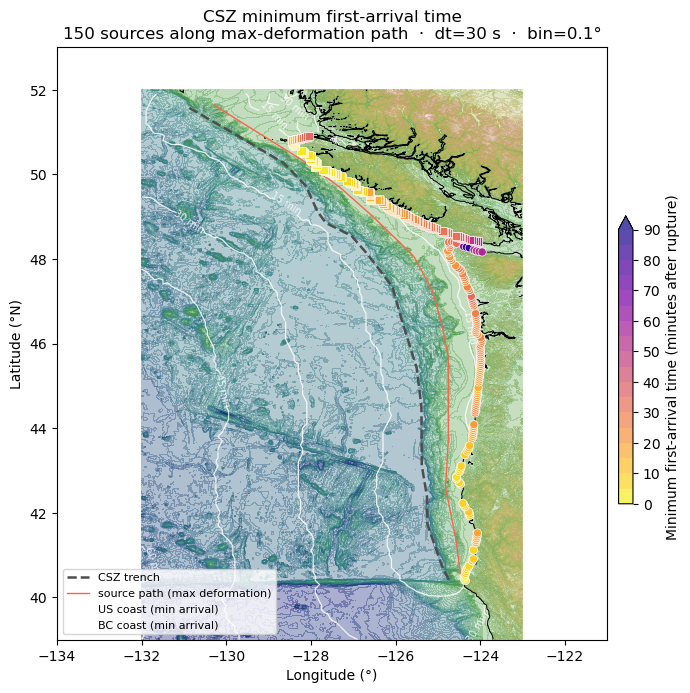

In [9]:
# ── shared colour scale ───────────────────────────────────────────────────────
# Cap display at 90 min so the near-coast colour variation is visible
TT_MAX_DISPLAY = 90.0   # minutes
tt_levels = np.arange(0, TT_MAX_DISPLAY + 5, 5)
cmap      = plt.get_cmap('plasma_r')
norm_tt   = mcolors.Normalize(vmin=0, vmax=TT_MAX_DISPLAY)

fig, ax = plt.subplots(figsize=(7, 10))

# ── bathymetry background ─────────────────────────────────────────────────────
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=100, cmap='gist_earth', norm=norm_bathy, alpha=0.35)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.7)

# ── travel time filled contours (background field) ────────────────────────────
#cf = ax.contourf(lon_bin, lat_bin, travel_time_min,
#                 levels=tt_levels, cmap=cmap, norm=norm_tt,
#                 alpha=0.72, extend='max')

# Isochrone lines every 15 min
cs = ax.contour(lon_bin, lat_bin, travel_time_min,
                levels=np.arange(15, TT_MAX_DISPLAY + 15, 15),
                colors='white', linewidths=0.9, alpha=0.85)
ax.clabel(cs, fmt='%d min', fontsize=7, inline=True)

# ── CSZ trench ────────────────────────────────────────────────────────────────
ax.plot(trench_raw[:, 0], trench_raw[:, 1],
        color='0.3', linewidth=1.8, linestyle='--', zorder=4, label='CSZ trench')

# ── source path ───────────────────────────────────────────────────────────────
ax.plot(src_lons, src_lats,
        color='tomato', linewidth=1.0, linestyle='-',
        zorder=4, label='source path (max deformation)')

# ── coastal receivers coloured by arrival time ────────────────────────────────
sc_us = ax.scatter(us_coast_lon, us_coast_lat,
                   c=us_arrival_min, cmap=cmap, norm=norm_tt,
                   s=35, marker='o', edgecolors='white', linewidths=0.5,
                   zorder=6, label='US coast (min arrival)')
sc_ca = ax.scatter(ca_coast_lon, ca_coast_lat,
                   c=ca_arrival_min, cmap=cmap, norm=norm_tt,
                   s=35, marker='s', edgecolors='white', linewidths=0.5,
                   zorder=6, label='BC coast (min arrival)')

ax.set_xlim([LON_MIN, LON_MAX])
ax.set_ylim([LAT_MIN, LAT_MAX])
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'CSZ minimum first-arrival time\n'
    f'{N_SOURCES} sources along max-deformation path  ·  '
    f'dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Minimum first-arrival time (minutes after rupture)')
plt.tight_layout()
plt.show()